Total samples: 1000
Train size: 700 (70.0%)
Val size:   150 (15.0%)
Test size:  150 (15.0%)
Best k on the validation set: 3. Accuracy: 80.00%


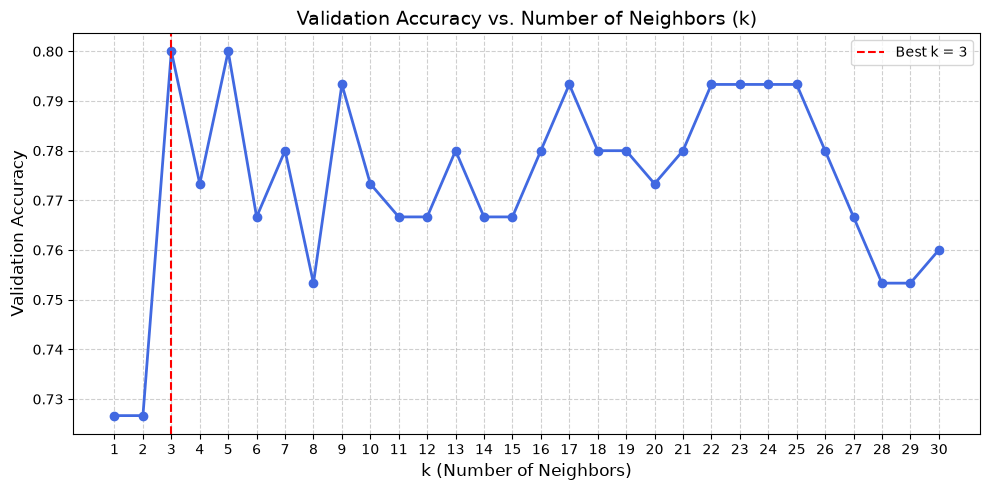

 Accuracy on the 15% cutoff test set using k = 3: 78.00%.
 Accuracy on the csv test set using k = 3: 75.45%.
 Accuracy of the 10-fold cross validation using k = 3: 78.30%.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = pd.read_csv("train_inputs.csv", header=None).values
y = pd.read_csv("train_labels.csv", header=None).values.ravel()



def knn_predict_single(X_train, y_train, query_point, k):
    '''
    Euclidean distance is sqrt(sum((x_train - query)^2))
    np.linalg.norm computes this across all rows at once
    distances holds all the distance values
    '''
    distances = np.linalg.norm(X_train - query_point, axis=1)
    
    # Gets the smallest number of k indices and map them to train_labels
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]
    
    # Do the voting and figure out which class has more points closer to the given point
    count_5 = np.count_nonzero(k_labels == 5)
    count_6 = np.count_nonzero(k_labels == 6)

    
    if count_5 > count_6:
        return 5
    elif count_6 > count_5:
        return 6
    else:
        # The single nearest neighbor breaks the tie
        return k_labels[0]

# Check how accurate the runthrough was with the k value
'''
Using the validation cutoff as the query point, check if the returned class 
for the point matches the actual class of the point, and log the amount correct.
Return the % of amt correct.
''' 

def evaluate_accuracy(X_train, y_train, X_eval, y_eval, k):
    correct = 0
    
    for i in range(len(X_eval)):
        pred = knn_predict_single(X_train, y_train, X_eval[i], k)
        if pred == y_eval[i]:
            correct += 1
    return correct / len(y_eval)

# Fixed seed for reproducible splits
np.random.seed(42)

#Get the length of train_inputs and get a shuffled list
total_samples = len(X)
shuffled_indices = np.random.permutation(total_samples)

# Calculate amount of samples in each slice cutoff
train_end = int(0.70 * total_samples)
val_end = int(0.85 * total_samples)

# Get the indices for the training, validation, and testing cutoffs
train_idx = shuffled_indices[:train_end]
val_idx = shuffled_indices[train_end:val_end]
test_idx = shuffled_indices[val_end:]

# Split data into cutoffs, X for the train_inputs and y for the train_labels
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Print the total samples, the training size, the value size, and the test size
print(f"Total samples: {total_samples}")
print(f"Train size: {len(X_train)} ({len(X_train)/total_samples:.1%})")
print(f"Val size:   {len(X_val)} ({len(X_val)/total_samples:.1%})")
print(f"Test size:  {len(X_test)} ({len(X_test)/total_samples:.1%})")


k_values = list(range(1, 31))
val_accuracies = []

#run the previous functions
for k in k_values:
    acc = evaluate_accuracy(X_train, y_train, X_val, y_val, k)
    val_accuracies.append(acc)

# Get which k was best
best_val_acc = max(val_accuracies)
best_k = k_values[val_accuracies.index(best_val_acc)]

print(f"Best k on the validation set: {best_k}. Accuracy: {best_val_acc:.2%}")

# Pyplot 
plt.figure(figsize=(10, 5))
plt.plot(k_values, val_accuracies, marker='o', linewidth=2, color='royalblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')

plt.title("Validation Accuracy vs. Number of Neighbors (k)", fontsize=14)
plt.xlabel("k (Number of Neighbors)", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()




#2. Taking the best k value and running it on the 15% test_sets

acc = evaluate_accuracy(X_train, y_train, X_test, y_test, best_k)
print(f" Accuracy on the 15% cutoff test set using k = {best_k}: {acc:.2%}.")

#2b. Running the test_inputs and test_labels using the best_k
X2 = pd.read_csv("test_inputs.csv", header=None).values
y2 = pd.read_csv("test_labels.csv", header=None).values.ravel()

acc = evaluate_accuracy(X_train, y_train, X2, y2, best_k)
print(f" Accuracy on the csv test set using k = {best_k}: {acc:.2%}.")


#3. Running a 10-fold cross validation on the best number's of neighbors
def fold_testing(inputs, labels, k_best):
    total_samples = len(inputs)
    shuffled_indices = np.random.permutation(total_samples)
    # Split the indices list into 10 equal parts (folds)
    folds = np.array_split(shuffled_indices, 10)
    total_acc = 0
    #Loop through and test each singular fold on the rest of the folds till every fold has been tested
    for i in range(10):
        test_idx = folds[i]  
        train_idx = np.concatenate(folds[:i] + folds [i + 1:])


        X_train, y_train = inputs[train_idx], labels[train_idx]
        X_test, y_test = inputs[test_idx], labels[test_idx]

        #Keep track of the total accuracy
        total_acc += evaluate_accuracy(X_train, y_train, X_test, y_test, k_best)

    # Find the avg accuracy
    return total_acc / 10

acc = fold_testing(X, y, best_k)
print(f" Accuracy of the 10-fold cross validation using k = {best_k}: {acc:.2%}.")

